In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar


def heun_simulate_k(
    k,
    time,
    T_heater_0,
    T_sink,
    Q,
    m,
    Cp,
    A,
    L,
):
    """
    Simulate heater block temperature using Heun's method.

    Parameters
    ----------
    k : float
        Thermal conductivity (W/m-K)
    time : array
        Time vector [s]
    T_heater_0 : float
        Initial heater temperature [C]
    T_sink : array
        Measured sink temperatures [C]
    Q : float
        Heater power [W]
    m : float
        Heater block mass [kg]
    Cp : float
        Heater block specific heat [J/kg-K]
    A : float
        Heat transfer area [m^2]
    L : float
        Stack thickness [m]

    Returns
    -------
    T_pred : ndarray
        Predicted heater temperatures
    """

    C = m * Cp
    T_pred = np.zeros(len(time))
    T_pred[0] = T_heater_0

    for i in range(len(time) - 1):

        dt = time[i + 1] - time[i]

        def f(T, Ts):
            return (
                Q
                - (k * A / L) * (T - Ts)
            ) / C

        k1 = f(T_pred[i], T_sink[i])

        T_star = T_pred[i] + dt * k1

        k2 = f(T_star, T_sink[i + 1])

        T_pred[i + 1] = (
            T_pred[i]
            + 0.5 * dt * (k1 + k2)
        )

    return T_pred


def fit_k(
    time,
    T_heater_measured,
    T_sink_measured,
    Q,
    m,
    Cp,
    A,
    L,
    k_min=0.01,
    k_max=50,
):
    """
    Find conductivity that minimizes squared error.
    """

    def objective(k):

        T_pred = heun_simulate_k(
            k,
            time,
            T_heater_measured[0],
            T_sink_measured,
            Q,
            m,
            Cp,
            A,
            L,
        )

        return np.mean(
            (T_pred - T_heater_measured) ** 2
        )

    result = minimize_scalar(
        objective,
        bounds=(k_min, k_max),
        method="bounded",
    )

    return result.x, result.fun

import matplotlib.pyplot as plt


def plot_fit(
    time,
    T_heater_measured,
    T_sink_measured,
    k_fit,
    Q,
    m,
    Cp,
    A,
    L,
):
    """
    Plot measured heater temperature,
    measured sink temperature,
    and Heun model prediction.
    """

    T_model = heun_simulate_k(
        k_fit,
        time,
        T_heater_measured[0],
        T_sink_measured,
        Q,
        m,
        Cp,
        A,
        L,
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        time,
        T_heater_measured,
        "o",
        markersize=4,
        label="Measured Heater"
    )

    plt.plot(
        time,
        T_model,
        "-",
        linewidth=2,
        label=f"Heun Fit (k={k_fit:.3f} W/m-K)"
    )

    plt.plot(
        time,
        T_sink_measured,
        "--",
        linewidth=2,
        label="Measured Sink"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (C)")
    plt.title("Thermal Conductivity Fit")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

filename = "conduction3.csv"

# Read CSV
df = pd.read_csv(filename)

# Convert to seconds
df["time_sec"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0

df["delta_T"] = df["temp1_c"] - df["temp2_c"]

Best fit k = 15.448481010725333 W/m-K
MSE = 3.7723200616411754


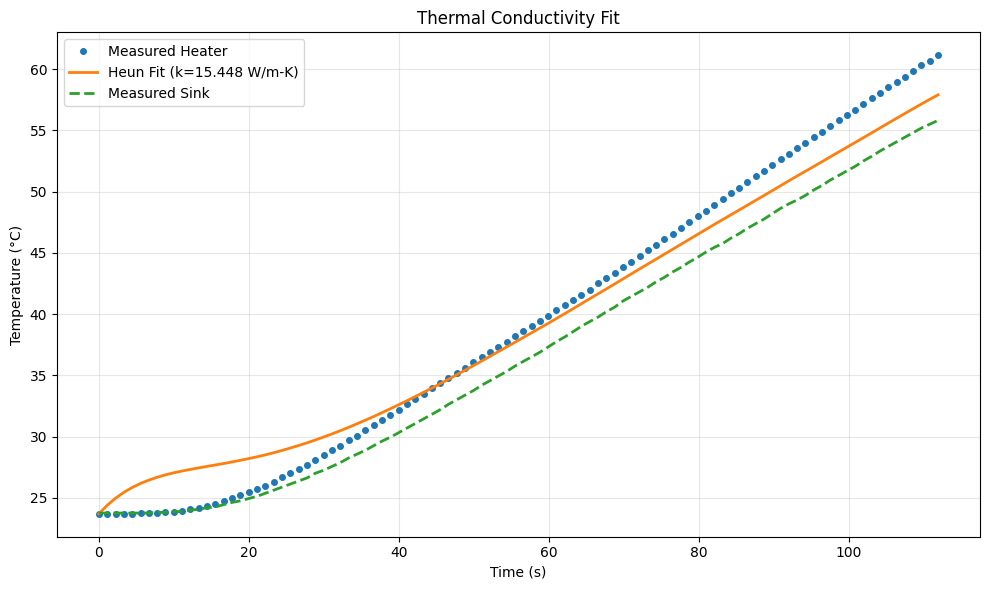

In [4]:
import numpy as np

time = df["time_sec"].to_numpy()
T_hot = df["temp1_c"].to_numpy()
T_cold = df["temp2_c"].to_numpy()

k_fit, mse = fit_k(
    time=time,
    T_heater_measured=T_hot,
    T_sink_measured=T_cold,
    Q=30.0,          # W
    m=0.050,         # kg
    Cp=880,          # J/kg-K
    A=0.00145,       # m^2
    L=0.003,        # m
)

print("Best fit k =", k_fit, "W/m-K")
print("MSE =", mse)

plot_fit(
    time=time,
    T_heater_measured=T_hot,
    T_sink_measured=T_cold,
    k_fit=k_fit,
    Q=30.0,
    m=0.050,
    Cp=880,
    A=0.00145,
    L=0.003,
)